# Pseudobulk transcriptomics of CD19 CAR T-cell infusion products

**Dataset:** Single cell RNA-seq of CD19 CAR T-cell infusion products ([Deng et al., Nat Med 2020](https://doi.org/10.1038/s41591-020-1061-7)), 133,405 cells from 24 patients, distributed via CZ CELLxGENE.

**Contrast of interest:** within the **non-exhausted** T-cell compartment, we compare **CAR+ (transduced)** vs **CAR- (non-transduced)** cells &mdash; i.e. what changes transcriptionally when a T cell carries the CAR transgene, holding exhaustion state fixed.

**Workflow:**
1. Load precomputed pseudobulk profiles and visualize the full pseudobulk landscape (UMAP), tagging the case/control groups.
2. QC and filter the pseudobulk profiles.
3. Differential expression with `pydeseq2` (paired by donor).
4. Functional interpretation with `decoupler` (ORA on MSigDB Hallmarks, GSEA on PROGENy, TF activity via CollecTRI / `omnipath`).
5. Cell-cell communication with `liana+` to see how *other* cell types' ligand-receptor interactions with a given T-cell subset are gained/lost once that subset becomes CAR-transduced.

All analysis runs in the `sysbio` conda environment.


## How the pseudobulk profiles were built (read this first)

**You will not have access to the original single-cell file in this notebook** &mdash; we start directly from a precomputed pseudobulk file, `pb_full.h5ad`. This section explains what that means and why.

Single-cell RNA-seq counts are sparse and noisy, and a dataset's thousands of cells from the same patient are *not* independent biological replicates &mdash; feeding them directly into a bulk differential-expression tool like DESeq2 would massively overstate statistical confidence (a classic "pseudoreplication" error). The standard fix is **pseudobulking**: sum the raw UMI counts of all cells that share the same combination of biological labels of interest, producing one aggregated "sample" per combination. The result looks just like an ordinary bulk RNA-seq count table (one row of gene counts per sample), but each row still carries information about which patient, cell type, and condition it came from.

For this dataset, single cells were grouped by **donor x cell type x CAR status x exhaustion status**, and raw counts were summed within every group containing at least 10 cells:

- **`donor_id`** &mdash; the true biological replicate unit (one CAR T-cell infusion product per patient). This is what later allows a *paired* statistical design (each donor contributing both a CAR+ and a CAR- sample).
- **`cell_type_in_paper`** &mdash; the authors' cell-type annotation. Pooling cell types together before aggregating would confound any CAR+/CAR- signal with shifts in cell-type composition between samples.
- **`CAR`** (CAR+ / CAR-) &mdash; the transduction status, and our condition of interest: CAR+ cells carry the engineered CAR transgene ("transformed"), CAR- cells do not ("non-transformed").
- **`exhaustion_status`** &mdash; exhaustion is a major, largely independent source of transcriptional variation in T cells. We hold it fixed (non-exhausted only) for the primary contrast so it does not get entangled with the CAR effect.

This aggregation was performed once, offline, by [`build_pseudobulk.py`](build_pseudobulk.py) in this repository, which: (1) downloads the ~1.6 GB raw single-cell `.h5ad` file from [CZ CELLxGENE Discover](https://datasets.cellxgene.cziscience.com/25735b46-c216-43fb-8cae-5b890090b714.h5ad) if it is not already present, (2) sums raw counts within every donor x cell type x CAR x exhaustion group (>=10 cells), and (3) writes the result to `pb_full.h5ad` (738 samples x 19,522 genes). **The raw single-cell file itself is about 35x larger than the pseudobulk file and is not needed once this aggregation is done** &mdash; which is exactly why this notebook loads `pb_full.h5ad` directly instead.

One more derived object, `pb_bulk` (donor x CAR only, pooling all cell types within the non-exhausted compartment, used for the DESeq2 contrast), is built *inside this notebook* from `pb_full` &mdash; see the note in Section 1 below for exactly how and why.

## Environment setup (Colab-friendly)

This notebook is self-contained: running the next cell will

1. **Install any missing Python packages** (`scanpy`, `anndata`, `pydeseq2`, `decoupler`, `omnipath`, `liana`, `plotnine`, `adjustText`, `gdown`) — skipped automatically if they are already present (e.g. in the `sysbio` conda environment).
2. **Download one small precomputed pseudobulk file** (`pb_full.h5ad`, ~46 MB) from Google Drive if it is not already sitting in the working directory.

We start from a precomputed pseudobulk profile rather than the original ~1.6 GB single-cell object because the latter is too heavy for a free Colab runtime (see the section just above for what pseudobulking means and how this file was built).

**Before running this notebook on Colab**, upload `pb_full.h5ad` to your Google Drive, set sharing to "Anyone with the link", and paste its file ID into `PB_FULL_DRIVE_ID` in the next code cell (the ID is the long string in the share link: `https://drive.google.com/file/d/<ID>/view`).

You can just run the whole notebook top-to-bottom, on a local environment or on a fresh Google Colab runtime.

In [1]:
import importlib
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

# (import name -> pip spec). Versions are pinned for the packages whose APIs
# changed across recent releases (decoupler v2, liana, pydeseq2, plotnine).
REQUIRED_PACKAGES = {
    "scanpy": "scanpy>=1.10",
    "anndata": "anndata>=0.10",
    "pydeseq2": "pydeseq2==0.5.4",
    "decoupler": "decoupler==2.1.6",
    "omnipath": "omnipath==1.0.12",
    "liana": "liana==1.7.3",
    "plotnine": "plotnine==0.15.7",
    "adjustText": "adjustText==1.4.0",
    "gdown": "gdown",
}

missing_specs = []
for module_name, pip_spec in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing_specs.append(pip_spec)

if missing_specs:
    print(f"Installing {len(missing_specs)} missing package(s): {', '.join(missing_specs)}")
    print("(first run only - this can take a few minutes, e.g. on a fresh Colab runtime)")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing_specs],
        check=True,
    )
    print("Done installing packages.")
else:
    print("All required packages are already installed.")


All required packages are already installed.


## 0. Setup: imports, style, and consistent color palettes


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from adjustText import adjust_text
import requests

import decoupler as dc
import liana as li
import plotnine as p9
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sc.settings.verbosity = 1
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

H5AD_IN = "25735b46-c216-43fb-8cae-5b890090b714.h5ad"

# Colors used consistently across every figure in this notebook
CAR_PALETTE = {"CAR+": "#D62728", "CAR-": "#1F77B4"}
GROUP_PALETTE = {
    "case_CARpos_nonexhausted": "#D62728",
    "control_CARneg_nonexhausted": "#1F77B4",
    "other_exhausted": "#BBBBBB",
}
GROUP_LABELS = {
    "case_CARpos_nonexhausted": "Case: CAR+ / non-exhausted",
    "control_CARneg_nonexhausted": "Control: CAR- / non-exhausted",
    "other_exhausted": "Other (exhausted, either CAR status)",
}


## 1. Load precomputed pseudobulk profiles

We load a single pseudobulk object, **`pb_full`**, built ahead of time from the raw integer counts (`adata.raw.X`) of the original 133,405-cell single-cell dataset by summing cells within each donor x cell type x CAR status x exhaustion status group (groups with >=10 cells; see `build_pseudobulk.py`). This is the object used for the UMAP overview and the LIANA+ analysis.

For the case/control DESeq2 contrast we need a coarser object, **`pb_bulk`**: donor x CAR status, restricted to **non-exhausted** cells only, pooled across *all* cell types, so that every donor contributes exactly one CAR+ and one CAR- sample (a paired design). We derive `pb_bulk` directly from `pb_full` below by summing its non-exhausted, per-cell-type rows within each donor x CAR group.

Note this derivation is not perfectly equivalent to summing the raw single cells directly: `pb_full`'s per-(donor, cell type, CAR, exhaustion) `min_cells=10` filter already discarded a few small cell-type buckets before we get to aggregate them here, so some donor/CAR samples will have slightly fewer cells than if pooled straight from the raw data (worst case in this dataset: about 39% fewer cells in one sample). This is an acceptable trade-off for working from a single, small pseudobulk file.

In [3]:
# --- Fill this in after uploading pb_full.h5ad to Google Drive ---
# Right-click the file in Drive -> Share -> "Anyone with the link" -> Copy link.
# The link looks like: https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
# Paste just the <FILE_ID> portion below.
PB_FULL_DRIVE_ID = "10l2i1ZGPI7XDQPrccUm4GM9RMYfQSzc1"

PB_FULL_PATH = "pb_full.h5ad"


def fetch_from_drive(local_path, drive_id):
    if os.path.exists(local_path):
        print(f"Found existing local file: {local_path}")
        return
    if not drive_id or drive_id.startswith("REPLACE_WITH"):
        raise FileNotFoundError(
            f"{local_path} not found locally and no Google Drive file ID was provided. "
            f"Upload it to Google Drive, share it as \"Anyone with the link\", and set its ID above."
        )
    print(f"Downloading {local_path} from Google Drive (id={drive_id})...")
    gdown.download(id=drive_id, output=local_path, quiet=False)


import gdown

fetch_from_drive(PB_FULL_PATH, PB_FULL_DRIVE_ID)

pb_full = ad.read_h5ad(PB_FULL_PATH)
print("pb_full:", pb_full.shape)
print(pb_full.obs["group_tag"].value_counts())

# Derive pb_bulk (donor x CAR, non-exhausted, pooled across cell types) from pb_full
nonexh = pb_full[pb_full.obs["exhaustion_status"] == "non_exhausted"]
X_bulk, obs_bulk = [], []
for (donor, car), idx in nonexh.obs.groupby(["donor_id", "CAR"], observed=True).indices.items():
    X_bulk.append(np.asarray(nonexh.X[idx].sum(axis=0)).ravel())
    obs_bulk.append({"donor_id": donor, "CAR": car, "n_cells": int(nonexh.obs["n_cells"].iloc[idx].sum())})
obs_bulk = pd.DataFrame(obs_bulk)
obs_bulk.index = obs_bulk["donor_id"].astype(str) + "_" + obs_bulk["CAR"].astype(str)

pb_bulk = ad.AnnData(X=np.vstack(X_bulk).astype(np.float32), obs=obs_bulk, var=pb_full.var.copy())
pb_bulk.obs["CAR"] = pb_bulk.obs["CAR"].astype("category")
pb_bulk.obs["donor_id"] = pb_bulk.obs["donor_id"].astype("category")
pb_bulk.layers["counts"] = pb_bulk.X.copy()

print("\npb_bulk:", pb_bulk.shape)
print(pb_bulk.obs.groupby("CAR").size())
print("Donors with both CAR arms:", (pb_bulk.obs.groupby("donor_id").size() == 2).sum(), "/", pb_bulk.obs["donor_id"].nunique())


Found existing local file: pb_full.h5ad


pb_full: (738, 19522)
group_tag
other_exhausted                401
control_CARneg_nonexhausted    204
case_CARpos_nonexhausted       133
Name: count, dtype: int64



pb_bulk: (48, 19522)
CAR
CAR+    24
CAR-    24
dtype: int64
Donors with both CAR arms: 24 / 24


## 1b. UMAP overview of the pseudobulk landscape

We visualize all `pb_full` pseudobulk profiles (every donor x cell-type x CAR x exhaustion combination that passed the cell-count threshold), and look at the same embedding from three angles: which profiles are our case/control samples, which patient they come from, and which cell type they represent.


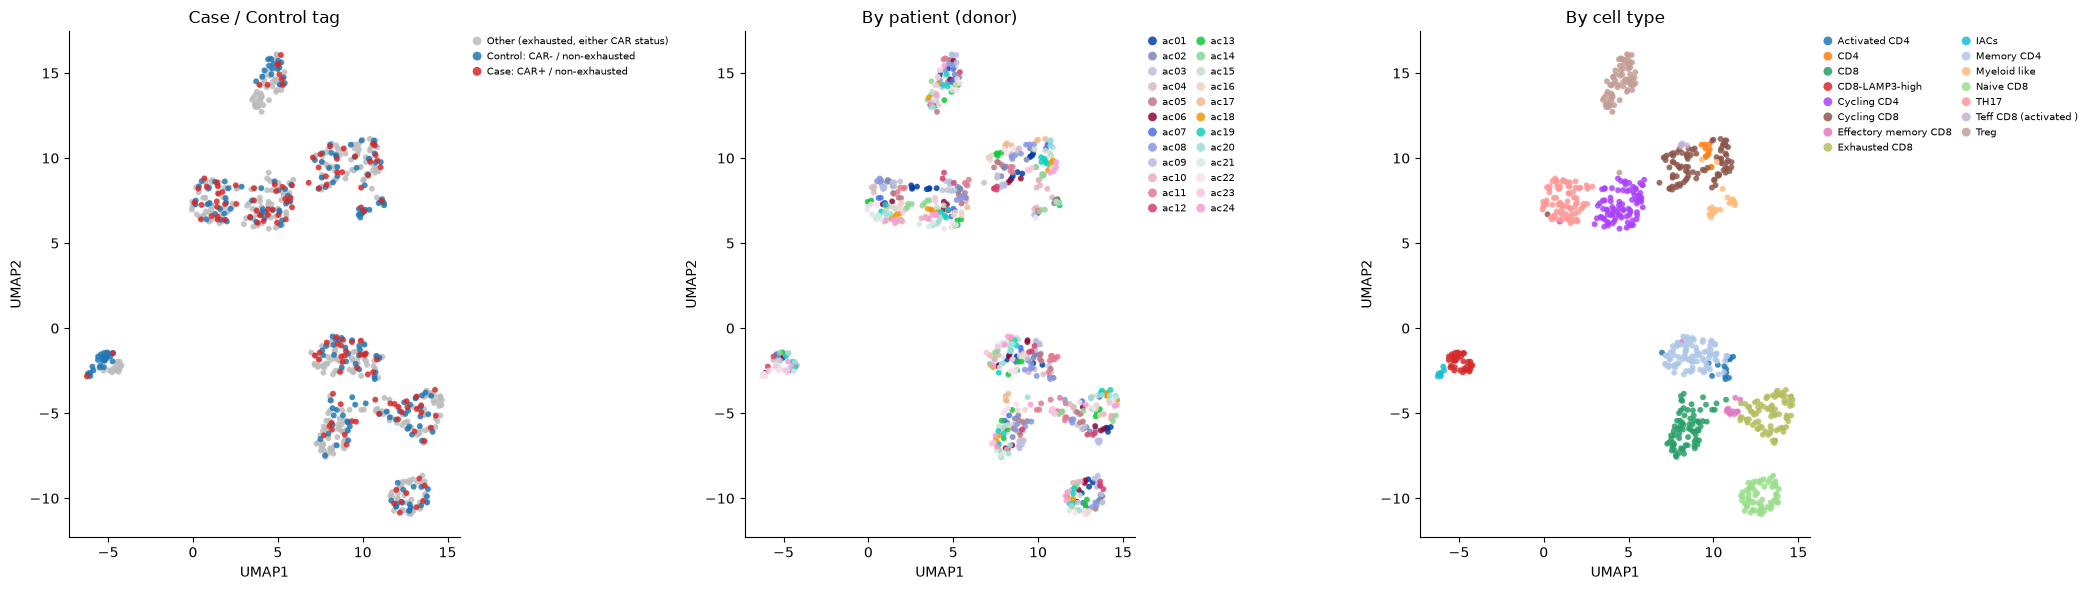

In [4]:
pb_vis = pb_full.copy()
sc.pp.normalize_total(pb_vis, target_sum=1e6)
sc.pp.log1p(pb_vis)
sc.pp.highly_variable_genes(pb_vis, n_top_genes=2000)
sc.pp.scale(pb_vis, max_value=10)
sc.tl.pca(pb_vis, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(pb_vis, n_neighbors=15)
sc.tl.umap(pb_vis, random_state=0)

donors = sorted(pb_vis.obs["donor_id"].unique())
cell_types = sorted(pb_vis.obs["cell_type_in_paper"].unique())
donor_palette = dict(zip(donors, sc.pl.palettes.default_28[:len(donors)]))
celltype_palette = dict(zip(cell_types, sc.pl.palettes.default_20[:len(cell_types)]))

um = pb_vis.obsm["X_umap"]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

group_order = ["other_exhausted", "control_CARneg_nonexhausted", "case_CARpos_nonexhausted"]
for ax, col, pal, order, title in [
    (axes[0], "group_tag", GROUP_PALETTE, group_order, "Case / Control tag"),
    (axes[1], "donor_id", donor_palette, donors, "By patient (donor)"),
    (axes[2], "cell_type_in_paper", celltype_palette, cell_types, "By cell type"),
]:
    for cat in order:
        m = (pb_vis.obs[col] == cat).values
        label = GROUP_LABELS.get(cat, cat) if col == "group_tag" else cat
        ax.scatter(um[m, 0], um[m, 1], s=18, c=[pal[cat]], label=label, alpha=0.85, edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ncol = 1 if len(pal) <= 12 else 2
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=7, ncol=ncol, markerscale=1.5)

plt.tight_layout()
plt.show()


**Reading the panels:** profiles cluster primarily by **cell type** (right panel) &mdash; the dominant axis of variation in the pseudobulk transcriptome is cell identity, not CAR/exhaustion status. The case (CAR+, red) and control (CAR-, blue) tags are scattered *within* each cell-type cluster, confirming that the CAR+/CAR- difference is a comparatively subtle, within-cell-type phenotypic shift rather than a distinct cell population &mdash; exactly the kind of effect a paired differential expression design is built to detect.


## 2. QC and filtering

We now focus on `pb_bulk` (donor x CAR, non-exhausted cells, all cell types pooled) &mdash; the object used for the DESeq2 contrast. We check library sizes, the number of genes detected per pseudobulk profile, and how these relate to the number of single cells that went into each sum (since these are summed raw counts, library size scales with cell count by construction).


,total_counts,n_genes_detected,n_cells
CAR,,,
CAR+,2566390.75,12988.3,335.9
CAR-,5688540.00,14317.5,974.8


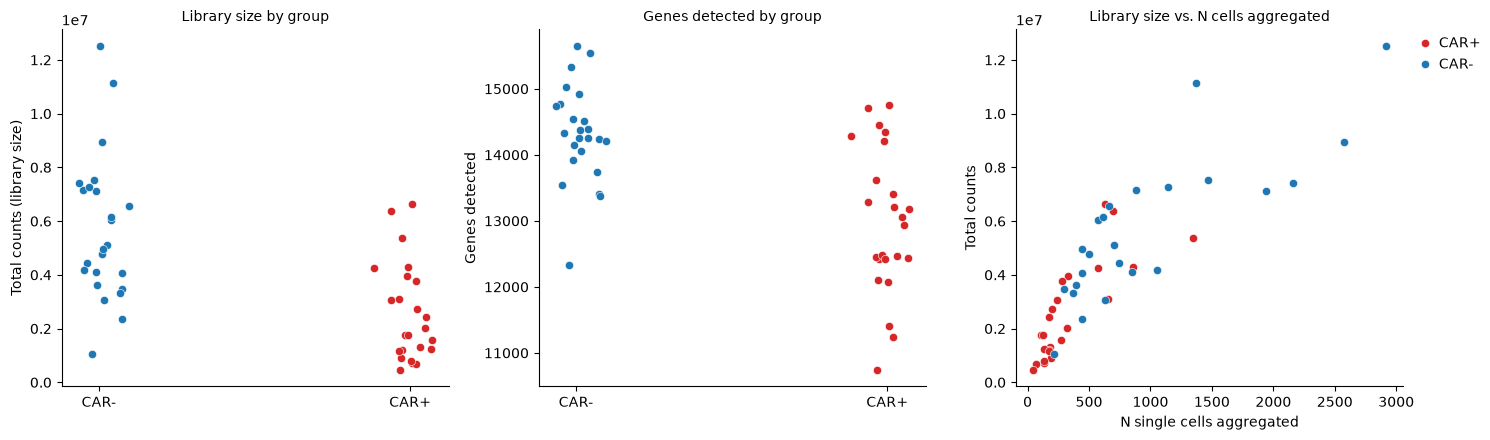

In [5]:
pb_bulk.obs["total_counts"] = np.asarray(pb_bulk.X.sum(axis=1)).ravel()
pb_bulk.obs["n_genes_detected"] = np.asarray((pb_bulk.X > 0).sum(axis=1)).ravel()

display(pb_bulk.obs.groupby("CAR")[["total_counts", "n_genes_detected", "n_cells"]].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
rng = np.random.default_rng(0)
for cat, color in CAR_PALETTE.items():
    sub = pb_bulk.obs[pb_bulk.obs["CAR"] == cat]
    x_jitter = rng.normal(0 if cat == "CAR-" else 1, 0.05, len(sub))
    axes[0].scatter(x_jitter, sub["total_counts"], c=color, label=cat, s=35, edgecolors="white", linewidths=0.4)
    axes[1].scatter(x_jitter, sub["n_genes_detected"], c=color, label=cat, s=35, edgecolors="white", linewidths=0.4)
    axes[2].scatter(sub["n_cells"], sub["total_counts"], c=color, label=cat, s=35, edgecolors="white", linewidths=0.4)

axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["CAR-", "CAR+"]); axes[0].set_ylabel("Total counts (library size)")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["CAR-", "CAR+"]); axes[1].set_ylabel("Genes detected")
axes[2].set_xlabel("N single cells aggregated"); axes[2].set_ylabel("Total counts")
axes[2].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
for ax, t in zip(axes, ["Library size by group", "Genes detected by group", "Library size vs. N cells aggregated"]):
    ax.set_title(t, fontsize=10)
plt.tight_layout()
plt.show()


CAR+ pseudobulk samples are built from fewer constituent single cells on average (CAR+ cells are rarer than CAR- in most infusion products), which is reflected directly in lower library sizes &mdash; this is expected from summed pseudobulk and is corrected for by DESeq2's internal size-factor normalization, not by further filtering here.

Next we drop lowly-expressed genes before fitting DESeq2 (standard practice: low-count genes contribute mostly noise and slow down dispersion estimation).


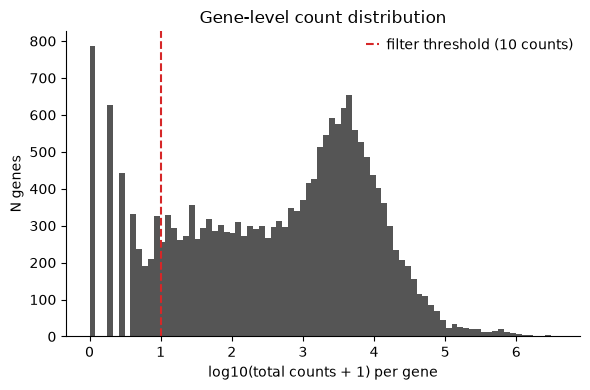

Genes before filtering: 19,522
Genes passing filter (sum>=10 counts & detected in >=20% of samples): 15,552


In [6]:
gene_sum = np.asarray(pb_bulk.X.sum(axis=0)).ravel()
gene_nsamples = np.asarray((pb_bulk.X > 0).sum(axis=0)).ravel()
keep_genes = (gene_sum >= 10) & (gene_nsamples >= 0.2 * pb_bulk.n_obs)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(gene_sum + 1), bins=80, color="#555555")
ax.axvline(np.log10(10), color="#D62728", ls="--", label="filter threshold (10 counts)")
ax.set_xlabel("log10(total counts + 1) per gene"); ax.set_ylabel("N genes")
ax.set_title("Gene-level count distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Genes before filtering: {pb_bulk.n_vars:,}")
print(f"Genes passing filter (sum>=10 counts & detected in >=20% of samples): {keep_genes.sum():,}")

pb_bulk_filt = pb_bulk[:, keep_genes].copy()


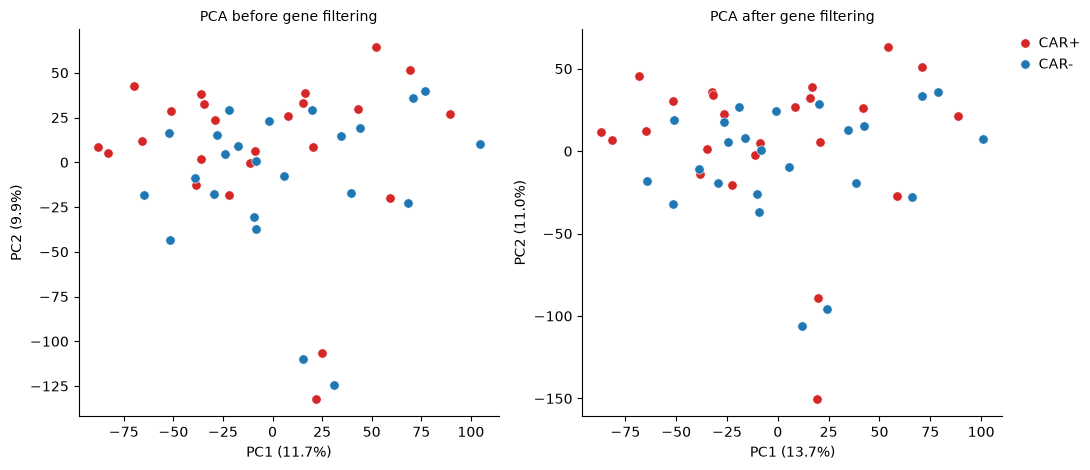

In [7]:
def quick_pca(adata_obj, title, ax):
    tmp = adata_obj.copy()
    sc.pp.normalize_total(tmp, target_sum=1e6)
    sc.pp.log1p(tmp)
    sc.pp.scale(tmp, max_value=10)
    sc.tl.pca(tmp, n_comps=10)
    var_ratio = tmp.uns["pca"]["variance_ratio"]
    for cat, color in CAR_PALETTE.items():
        m = (tmp.obs["CAR"] == cat).values
        ax.scatter(tmp.obsm["X_pca"][m, 0], tmp.obsm["X_pca"][m, 1], c=color, label=cat, s=45, edgecolors="white", linewidths=0.4)
    ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)")
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
quick_pca(pb_bulk, "PCA before gene filtering", axes[0])
quick_pca(pb_bulk_filt, "PCA after gene filtering", axes[1])
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


Gene filtering removes noise without disturbing the overall sample structure, as expected. We proceed to DESeq2 with `pb_bulk_filt`.


## 3. Differential expression with `pydeseq2`

`pb_bulk_filt` has exactly one CAR+ and one CAR- sample per donor, so we fit a **paired design** (`~donor_id + CAR`), which models out inter-patient variability before testing the CAR effect &mdash; analogous to a paired t-test, but for every gene at once.


In [8]:
counts_df = pd.DataFrame(pb_bulk_filt.X, index=pb_bulk_filt.obs_names, columns=pb_bulk_filt.var_names).astype(int)
meta_df = pb_bulk_filt.obs[["donor_id", "CAR"]].copy()

dds = DeseqDataSet(
    counts=counts_df,
    metadata=meta_df,
    design="~donor_id + CAR",
    ref_level=["CAR", "CAR-"],
    refit_cooks=True,
    quiet=True,
)
dds.deseq2()

stat = DeseqStats(dds, contrast=["CAR", "CAR+", "CAR-"], quiet=True)
stat.summary()
res = stat.results_df.copy()

gene_symbols = pb_bulk.var["feature_name"]
res["gene_symbol"] = gene_symbols.reindex(res.index)
res = res.dropna(subset=["padj"])

print(f"Genes tested: {len(res):,}")
print(f"Significant (padj<0.05): {(res['padj'] < 0.05).sum():,}")
print(f"Significant & |log2FC|>1: {((res['padj'] < 0.05) & (res['log2FoldChange'].abs() > 1)).sum():,}")
res.sort_values("padj").head(10)


Genes tested: 13,140
Significant (padj<0.05): 2,089
Significant & |log2FC|>1: 158


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_symbol
ENSG00000102962,321.831807,-6.441390,0.588008,-10.954589,6.316469e-28,8.299841e-24,CCL22
ENSG00000102970,648.565796,-6.711990,0.663273,-10.119494,4.527522e-24,2.974582e-20,CCL17
ENSG00000123349,1995.533675,-0.176396,0.018461,-9.554967,1.236234e-21,5.414704e-18,PFDN5
ENSG00000189067,613.306161,-0.415134,0.044829,-9.260292,2.038733e-20,5.596870e-17,LITAF
ENSG00000078081,36.621371,-3.138904,0.339135,-9.255630,2.129707e-20,5.596870e-17,LAMP3
ENSG00000085063,302.292678,0.324886,0.035549,9.139192,6.292064e-20,1.377962e-16,CD59
ENSG00000146278,277.624739,-0.659264,0.073348,-8.988161,2.514018e-19,4.719171e-16,PNRC1
ENSG00000162654,193.948513,-0.447954,0.050215,-8.920660,4.635157e-19,7.613246e-16,GBP4
ENSG00000118971,734.339589,0.282617,0.031754,8.900229,5.573169e-19,8.136827e-16,CCND2
ENSG00000101017,75.528339,-3.188615,0.361047,-8.831574,1.032132e-18,1.356221e-15,CD40


### Volcano plot


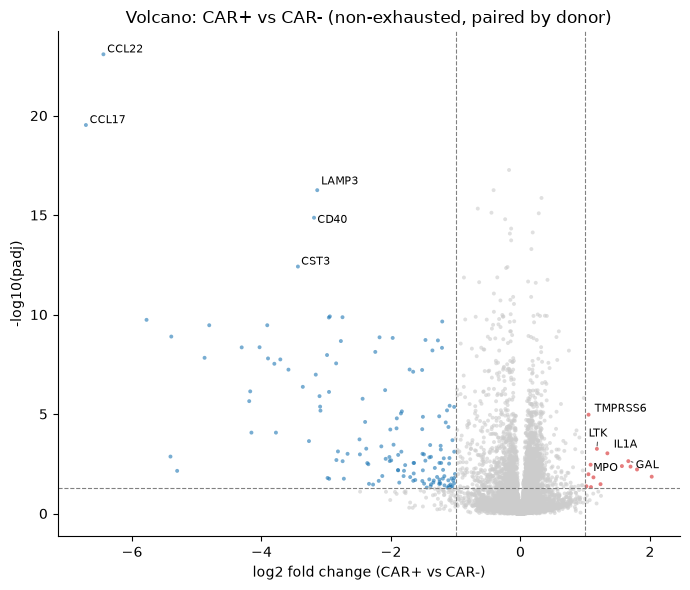

In [9]:
sig = res[(res["padj"] < 0.05) & (res["log2FoldChange"].abs() > 1)]
res["neglog10padj"] = -np.log10(res["padj"].clip(lower=1e-300))
colors = np.where((res["padj"] < 0.05) & (res["log2FoldChange"] > 1), CAR_PALETTE["CAR+"],
          np.where((res["padj"] < 0.05) & (res["log2FoldChange"] < -1), CAR_PALETTE["CAR-"], "#CCCCCC"))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(res["log2FoldChange"], res["neglog10padj"], c=colors, s=8, alpha=0.6, edgecolors="none")
ax.axvline(1, ls="--", c="gray", lw=0.8); ax.axvline(-1, ls="--", c="gray", lw=0.8)
ax.axhline(-np.log10(0.05), ls="--", c="gray", lw=0.8)
ax.set_xlabel("log2 fold change (CAR+ vs CAR-)"); ax.set_ylabel("-log10(padj)")
ax.set_title("Volcano: CAR+ vs CAR- (non-exhausted, paired by donor)")

top_up = sig[sig["log2FoldChange"] > 0].sort_values("padj").head(5)
top_dn = sig[sig["log2FoldChange"] < 0].sort_values("padj").head(5)
texts = [ax.text(row["log2FoldChange"], -np.log10(max(row["padj"], 1e-300)), row["gene_symbol"], fontsize=8)
         for _, row in pd.concat([top_up, top_dn]).iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.5))
plt.tight_layout()
plt.show()


### MA plot


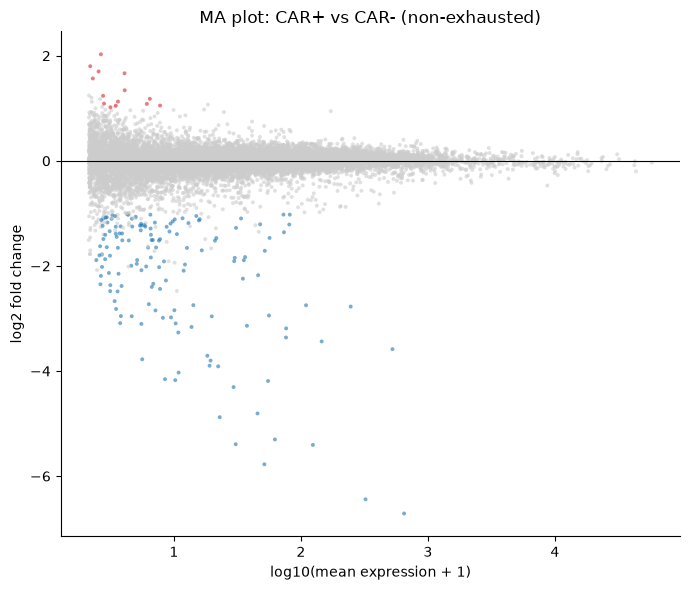

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(np.log10(res["baseMean"] + 1), res["log2FoldChange"], c=colors, s=8, alpha=0.6, edgecolors="none")
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("log10(mean expression + 1)"); ax.set_ylabel("log2 fold change")
ax.set_title("MA plot: CAR+ vs CAR- (non-exhausted)")
plt.tight_layout()
plt.show()


### Heatmap of the top 30 differentially expressed genes


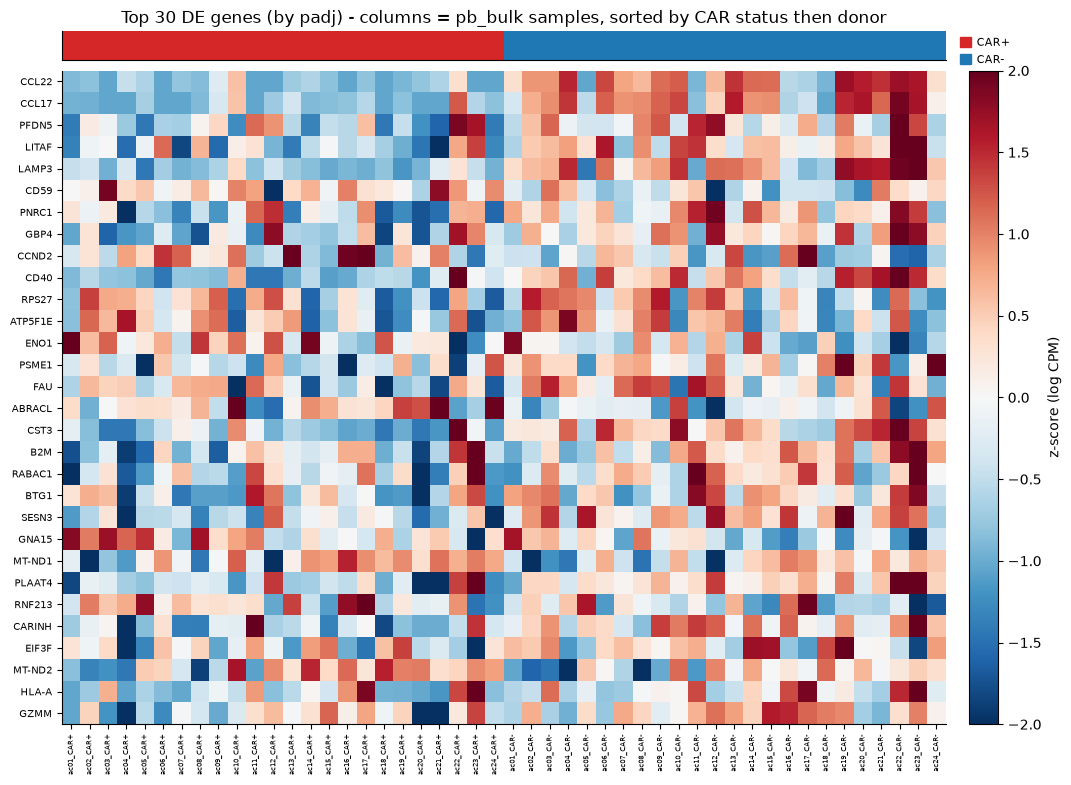

In [11]:
top_genes = res.sort_values("padj").head(30).index.tolist()

bulk_norm = pb_bulk.copy()
sc.pp.normalize_total(bulk_norm, target_sum=1e6)
sc.pp.log1p(bulk_norm)

mat = bulk_norm[:, top_genes].X
mat_z = (mat - mat.mean(axis=0)) / mat.std(axis=0)

order = bulk_norm.obs.sort_values(["CAR", "donor_id"]).index
mat_z_df = pd.DataFrame(mat_z, index=bulk_norm.obs_names,
                         columns=[gene_symbols.get(g, g) for g in top_genes]).loc[order]
car_colors = bulk_norm.obs.loc[order, "CAR"].map(CAR_PALETTE)

# ax_bar and ax_hm share column 0 of the gridspec (so they always have identical
# pixel width); the colorbar gets its own column 1, so attaching it never shrinks
# ax_hm relative to ax_bar the way `plt.colorbar(im, ax=ax_hm)` would.
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[0.4, 9], width_ratios=[30, 1], hspace=0.03, wspace=0.05)
ax_bar = fig.add_subplot(gs[0, 0])
ax_hm = fig.add_subplot(gs[1, 0], sharex=ax_bar)
cax = fig.add_subplot(gs[1, 1])

im = ax_hm.imshow(mat_z_df.T.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax_hm.set_yticks(range(len(top_genes))); ax_hm.set_yticklabels(mat_z_df.columns, fontsize=7)
ax_hm.set_xticks(range(len(order))); ax_hm.set_xticklabels(order, rotation=90, fontsize=5)
fig.colorbar(im, cax=cax, label="z-score (log CPM)")

car_rgb = np.array([mpl.colors.to_rgb(c) for c in car_colors.values]).reshape(1, -1, 3)
ax_bar.imshow(car_rgb, aspect="auto")
# sharex links the tick locator between ax_bar and ax_hm, so ax_bar's ticks must
# be cleared *after* ax_hm's are set, or ax_hm's labels bleed back onto ax_bar.
ax_bar.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)
ax_bar.set_yticks([])
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CAR_PALETTE.values()]
ax_bar.legend(handles, CAR_PALETTE.keys(), loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
ax_bar.set_title("Top 30 DE genes (by padj) - columns = pb_bulk samples, sorted by CAR status then donor")

fig.subplots_adjust(left=0.08, right=0.86, top=0.95, bottom=0.18)
plt.show()


### Top 5 up- and down-regulated genes, with full gene names

We pull full gene descriptions from [mygene.info](https://mygene.info) for readability.


In [12]:
top10 = pd.concat([top_up.assign(direction="up"), top_dn.assign(direction="down")])
full_names = []
for sym in top10["gene_symbol"]:
    try:
        r = requests.get("https://mygene.info/v3/query",
                          params={"q": f"symbol:{sym}", "species": "human", "fields": "name,symbol"}, timeout=8)
        hits = r.json().get("hits", [])
        full_names.append(hits[0]["name"] if hits else "NA")
    except Exception:
        full_names.append("NA")
top10["full_name"] = full_names

top10_display = top10[["gene_symbol", "full_name", "log2FoldChange", "padj", "direction"]].reset_index(drop=True)
top10_display


,gene_symbol,full_name,log2FoldChange,padj,direction
0,TMPRSS6,transmembrane serine protease 6,1.051797,1.075503e-05,up
1,LTK,leukocyte receptor tyrosine kinase,1.180447,5.597474e-04,up
2,IL1A,interleukin 1 alpha,1.342447,9.397601e-04,up
3,GAL,galanin and GMAP prepropeptide,1.665962,2.325801e-03,up
4,MPO,myeloperoxidase,1.083333,3.517069e-03,up
5,CCL22,C-C motif chemokine ligand 22,-6.441390,8.299841e-24,down
6,CCL17,C-C motif chemokine ligand 17,-6.711990,2.974582e-20,down
7,LAMP3,lysosome associated membrane protein 3,-3.138904,5.596870e-17,down
8,CD40,CD40 molecule,-3.188615,1.356221e-15,down
9,CST3,cystatin C,-3.437312,3.860143e-13,down


## 4. Functional enrichment with `decoupler`

We rank genes by their DESeq2 Wald statistic and interrogate three complementary resources, all imported through `decoupler`'s `omnipath`-backed connectors:

- **4.1** Over-Representation Analysis (ORA) of the top 100 up- and top 100 down-regulated genes against **MSigDB Hallmarks**.
- **4.2** Gene Set Enrichment Analysis (GSEA) of the full ranked gene list against **PROGENy** pathway signatures.
- **4.3** Transcription factor activity via a Univariate Linear Model (ULM) against the **CollecTRI** TF-target network (sourced from `omnipath`).


In [13]:
res_ranked = res.dropna(subset=["gene_symbol"]).sort_values("stat", ascending=False).drop_duplicates("gene_symbol", keep="first")
mat = res_ranked.set_index("gene_symbol")[["stat"]].T
mat.index = ["CARpos_vs_CARneg"]
mat_neg = -mat
stat_df = res_ranked.set_index("gene_symbol")[["stat"]]

print(f"Ranked gene matrix: {mat.shape[1]} genes, contrast '{mat.index[0]}'")


Ranked gene matrix: 13140 genes, contrast 'CARpos_vs_CARneg'


### 4.1 ORA against MSigDB Hallmarks (top 100 up vs. top 100 down)


Hallmark resource: 7318 gene-set memberships across 50 hallmarks


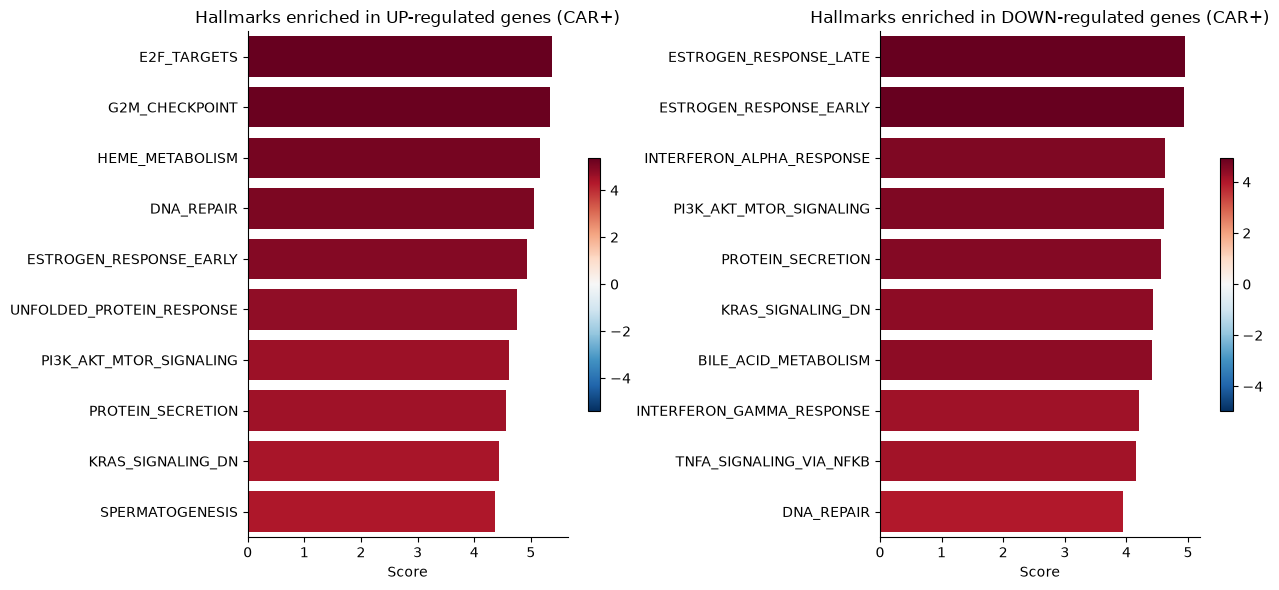

In [14]:
hallmark = dc.op.hallmark(organism="human")
print(f"Hallmark resource: {hallmark.shape[0]} gene-set memberships across {hallmark['source'].nunique()} hallmarks")

es_up, p_up = dc.mt.ora(mat, hallmark, n_up=100, n_bm=0, verbose=False)
es_dn, p_dn = dc.mt.ora(mat_neg, hallmark, n_up=100, n_bm=0, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
dc.pl.barplot(es_up, name="CARpos_vs_CARneg", top=10, ax=axes[0])
axes[0].set_title("Hallmarks enriched in UP-regulated genes (CAR+)")
dc.pl.barplot(es_dn, name="CARpos_vs_CARneg", top=10, ax=axes[1])
axes[1].set_title("Hallmarks enriched in DOWN-regulated genes (CAR+)")
plt.tight_layout()
plt.show()


### 4.2 GSEA against PROGENy pathway signatures


PROGENy resource: 6463 gene weights across 14 pathways


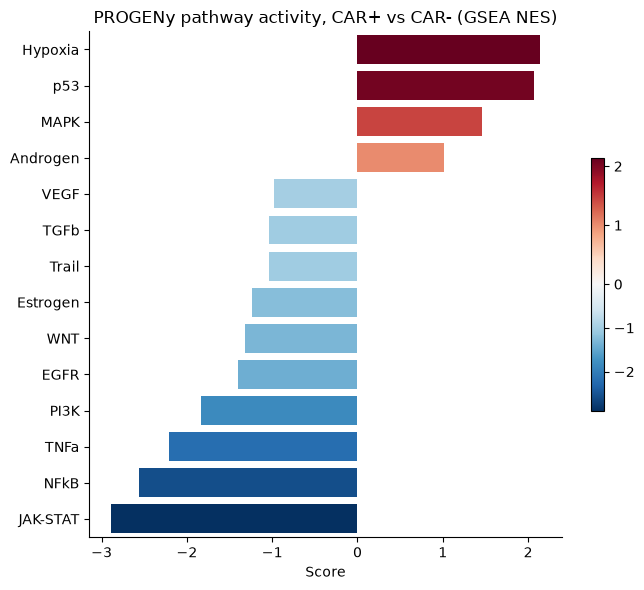

In [15]:
progeny = dc.op.progeny(organism="human", top=500)
print(f"PROGENy resource: {progeny.shape[0]} gene weights across {progeny['source'].nunique()} pathways")

es_progeny, p_progeny = dc.mt.gsea(mat, progeny, verbose=False)

fig, ax = plt.subplots(figsize=(7, 6))
dc.pl.barplot(es_progeny, name="CARpos_vs_CARneg", top=14, ax=ax)
ax.set_title("PROGENy pathway activity, CAR+ vs CAR- (GSEA NES)")
plt.tight_layout()
plt.show()


### 4.3 Transcription factor activity (ULM) using CollecTRI from `omnipath`


CollecTRI network: 42990 TF-target edges across 1185 TFs


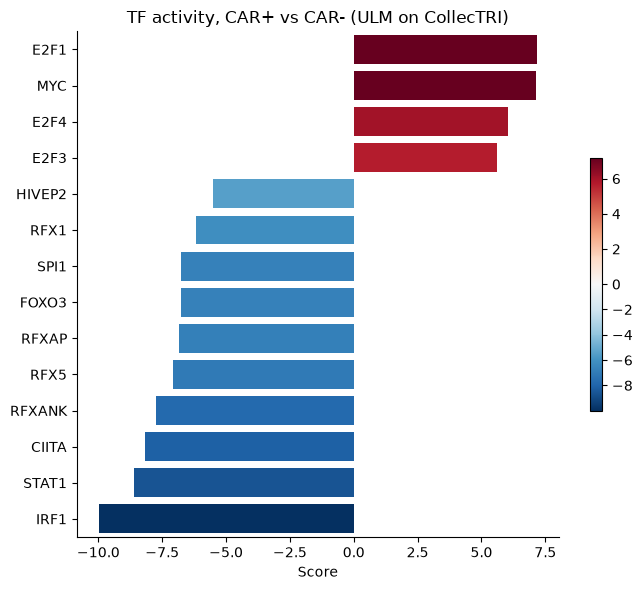

In [16]:
collectri = dc.op.collectri(organism="human")
print(f"CollecTRI network: {collectri.shape[0]} TF-target edges across {collectri['source'].nunique()} TFs")

es_tf, p_tf = dc.mt.ulm(mat, collectri, verbose=False)

fig, ax = plt.subplots(figsize=(7, 6))
dc.pl.barplot(es_tf, name="CARpos_vs_CARneg", top=14, ax=ax)
ax.set_title("TF activity, CAR+ vs CAR- (ULM on CollecTRI)")
plt.tight_layout()
plt.show()


### Leading-edge genes driving the top hallmark and the top TF

For the strongest up-regulated hallmark and the strongest down-regulated TF, we plot the GSEA-style running-enrichment curve, which marks the specific genes ("leading edge") responsible for the signal.


Top up-regulated hallmark: E2F_TARGETS
Top down-regulated TF: IRF1


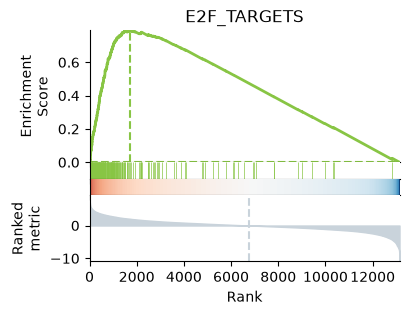

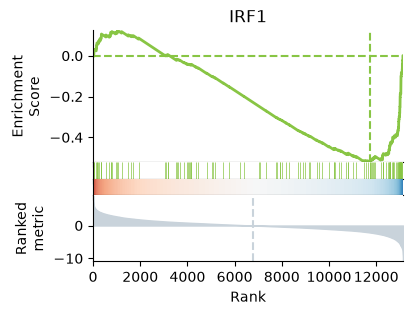


Leading-edge genes for E2F_TARGETS:
 [np.str_('JPT1'), np.str_('HMGA1'), np.str_('UBE2S'), np.str_('CKS2'), np.str_('AURKA'), np.str_('RAN'), np.str_('SNRPB'), np.str_('KIF22'), np.str_('TRIP13'), np.str_('PA2G4'), np.str_('RAD21'), np.str_('HNRNPD'), np.str_('MYBL2'), np.str_('PAICS'), np.str_('MTHFD2')]

Leading-edge genes for IRF1 targets:
 [np.str_('CD40'), np.str_('HLA-A'), np.str_('TRIM22'), np.str_('IDO1'), np.str_('CCL19'), np.str_('IRF1'), np.str_('TAPBP'), np.str_('HLA-E'), np.str_('LYZ'), np.str_('IL15'), np.str_('BIRC3'), np.str_('CD200'), np.str_('CD74'), np.str_('TNFSF13B'), np.str_('CASP1')]


In [17]:
top_hallmark_up = es_up.iloc[0].idxmax()
top_tf_down = es_tf.iloc[0].idxmin()
print(f"Top up-regulated hallmark: {top_hallmark_up}")
print(f"Top down-regulated TF: {top_tf_down}")

fig1, le_hallmark = dc.pl.leading_edge(stat_df, net=hallmark, stat="stat", name=top_hallmark_up, return_fig=True)
plt.show()

fig2, le_tf = dc.pl.leading_edge(stat_df, net=collectri, stat="stat", name=top_tf_down, return_fig=True)
plt.show()

print(f"\nLeading-edge genes for {top_hallmark_up}:\n", list(le_hallmark[:15]))
print(f"\nLeading-edge genes for {top_tf_down} targets:\n", list(le_tf[:15]))


**Interpretation:** the three independent methods tell a coherent story. Genes **up** in CAR+ cells are dominated by **E2F_TARGETS / G2M_CHECKPOINT / MYC_TARGETS** (Hallmarks) and driven by **E2F1/E2F4/MYC** TF activity &mdash; a proliferation signature. Genes **down** in CAR+ cells are enriched for **interferon-gamma response / antigen presentation**, driven by loss of **IRF1, STAT1, CIITA, RFX5** activity (the MHC-II regulatory module). This is consistent with CAR transduction pushing non-exhausted T cells toward a more proliferative, less antigen-presentation-like state.


## 5. Ligand-receptor analysis with `liana+`

We now ask a more targeted question, in line with the rest of the notebook's CAR+ vs CAR- contrast: **how does the way *other* cell types communicate with a given T-cell subset change once that subset becomes CAR-transduced?** Autocrine signaling (a cell type talking to itself) does not answer that question, so we exclude same-cell-type pairs throughout this section and keep only **cross-cell-type** ligand-receptor interactions.

`liana+`'s standard methods expect a `groupby` column over which to compute per-group expression statistics. We build, for each condition (CAR+ and CAR- non-exhausted), a small AnnData where each "cell" is actually one **donor's pseudobulk profile for a given cell type** &mdash; i.e. donors act as the replicate units within each cell-type group. We restrict to cell types with at least 5 donors represented in *both* conditions, run `liana`'s `rank_aggregate` consensus method separately per condition, drop same-cell-type (source == target) pairs, and then compare the resulting cross-cell-type interaction rankings to find ligand-receptor pairs that are **gained or lost** when the target/source cell type becomes CAR+.

In [18]:
pb_lr = pb_full.copy()
pb_lr.var_names = pb_lr.var["feature_name"].astype(str)
pb_lr.var_names_make_unique()

MIN_DONORS = 5
coverage = (
    pb_lr.obs[pb_lr.obs["group_tag"] != "other_exhausted"]
    .groupby(["cell_type_in_paper", "group_tag"], observed=True).size()
    .unstack(fill_value=0)
)
usable_cts = coverage[
    (coverage["case_CARpos_nonexhausted"] >= MIN_DONORS) & (coverage["control_CARneg_nonexhausted"] >= MIN_DONORS)
].index.tolist()
print("Cell types usable for LIANA+ (>=5 donors in both conditions):")
display(coverage.loc[usable_cts])


Cell types usable for LIANA+ (>=5 donors in both conditions):


group_tag,case_CARpos_nonexhausted,control_CARneg_nonexhausted
cell_type_in_paper,,
CD8,11,18
Cycling CD4,21,21
Cycling CD8,19,23
Exhausted CD8,16,21
Memory CD4,21,22
Naive CD8,9,17
TH17,19,20
Treg,8,16


In [19]:
liana_results = {}
for tag in ["case_CARpos_nonexhausted", "control_CARneg_nonexhausted"]:
    sub = pb_lr[(pb_lr.obs["group_tag"] == tag) & (pb_lr.obs["cell_type_in_paper"].isin(usable_cts))].copy()
    sc.pp.normalize_total(sub, target_sum=1e6)
    sc.pp.log1p(sub)
    sub.obs["cell_type_in_paper"] = sub.obs["cell_type_in_paper"].astype(str).astype("category")

    res = li.mt.rank_aggregate(
        sub, groupby="cell_type_in_paper", resource_name="consensus",
        expr_prop=0.1, min_cells=MIN_DONORS, use_raw=False, n_perms=200,
        verbose=False, inplace=False, seed=0,
    )
    n_before = res.shape[0]
    res = res[res["source"] != res["target"]].reset_index(drop=True)  # keep cross-cell-type pairs only
    liana_results[tag] = res
    print(f"{tag}: {n_before} ligand-receptor x cell-type-pair rows, {res.shape[0]} after excluding same-cell-type (autocrine) pairs")


case_CARpos_nonexhausted: 43177 ligand-receptor x cell-type-pair rows, 37746 after excluding same-cell-type (autocrine) pairs


control_CARneg_nonexhausted: 48554 ligand-receptor x cell-type-pair rows, 42425 after excluding same-cell-type (autocrine) pairs


### Top cross-cell-type interactions within the CAR+ (case) and CAR- (control) conditions

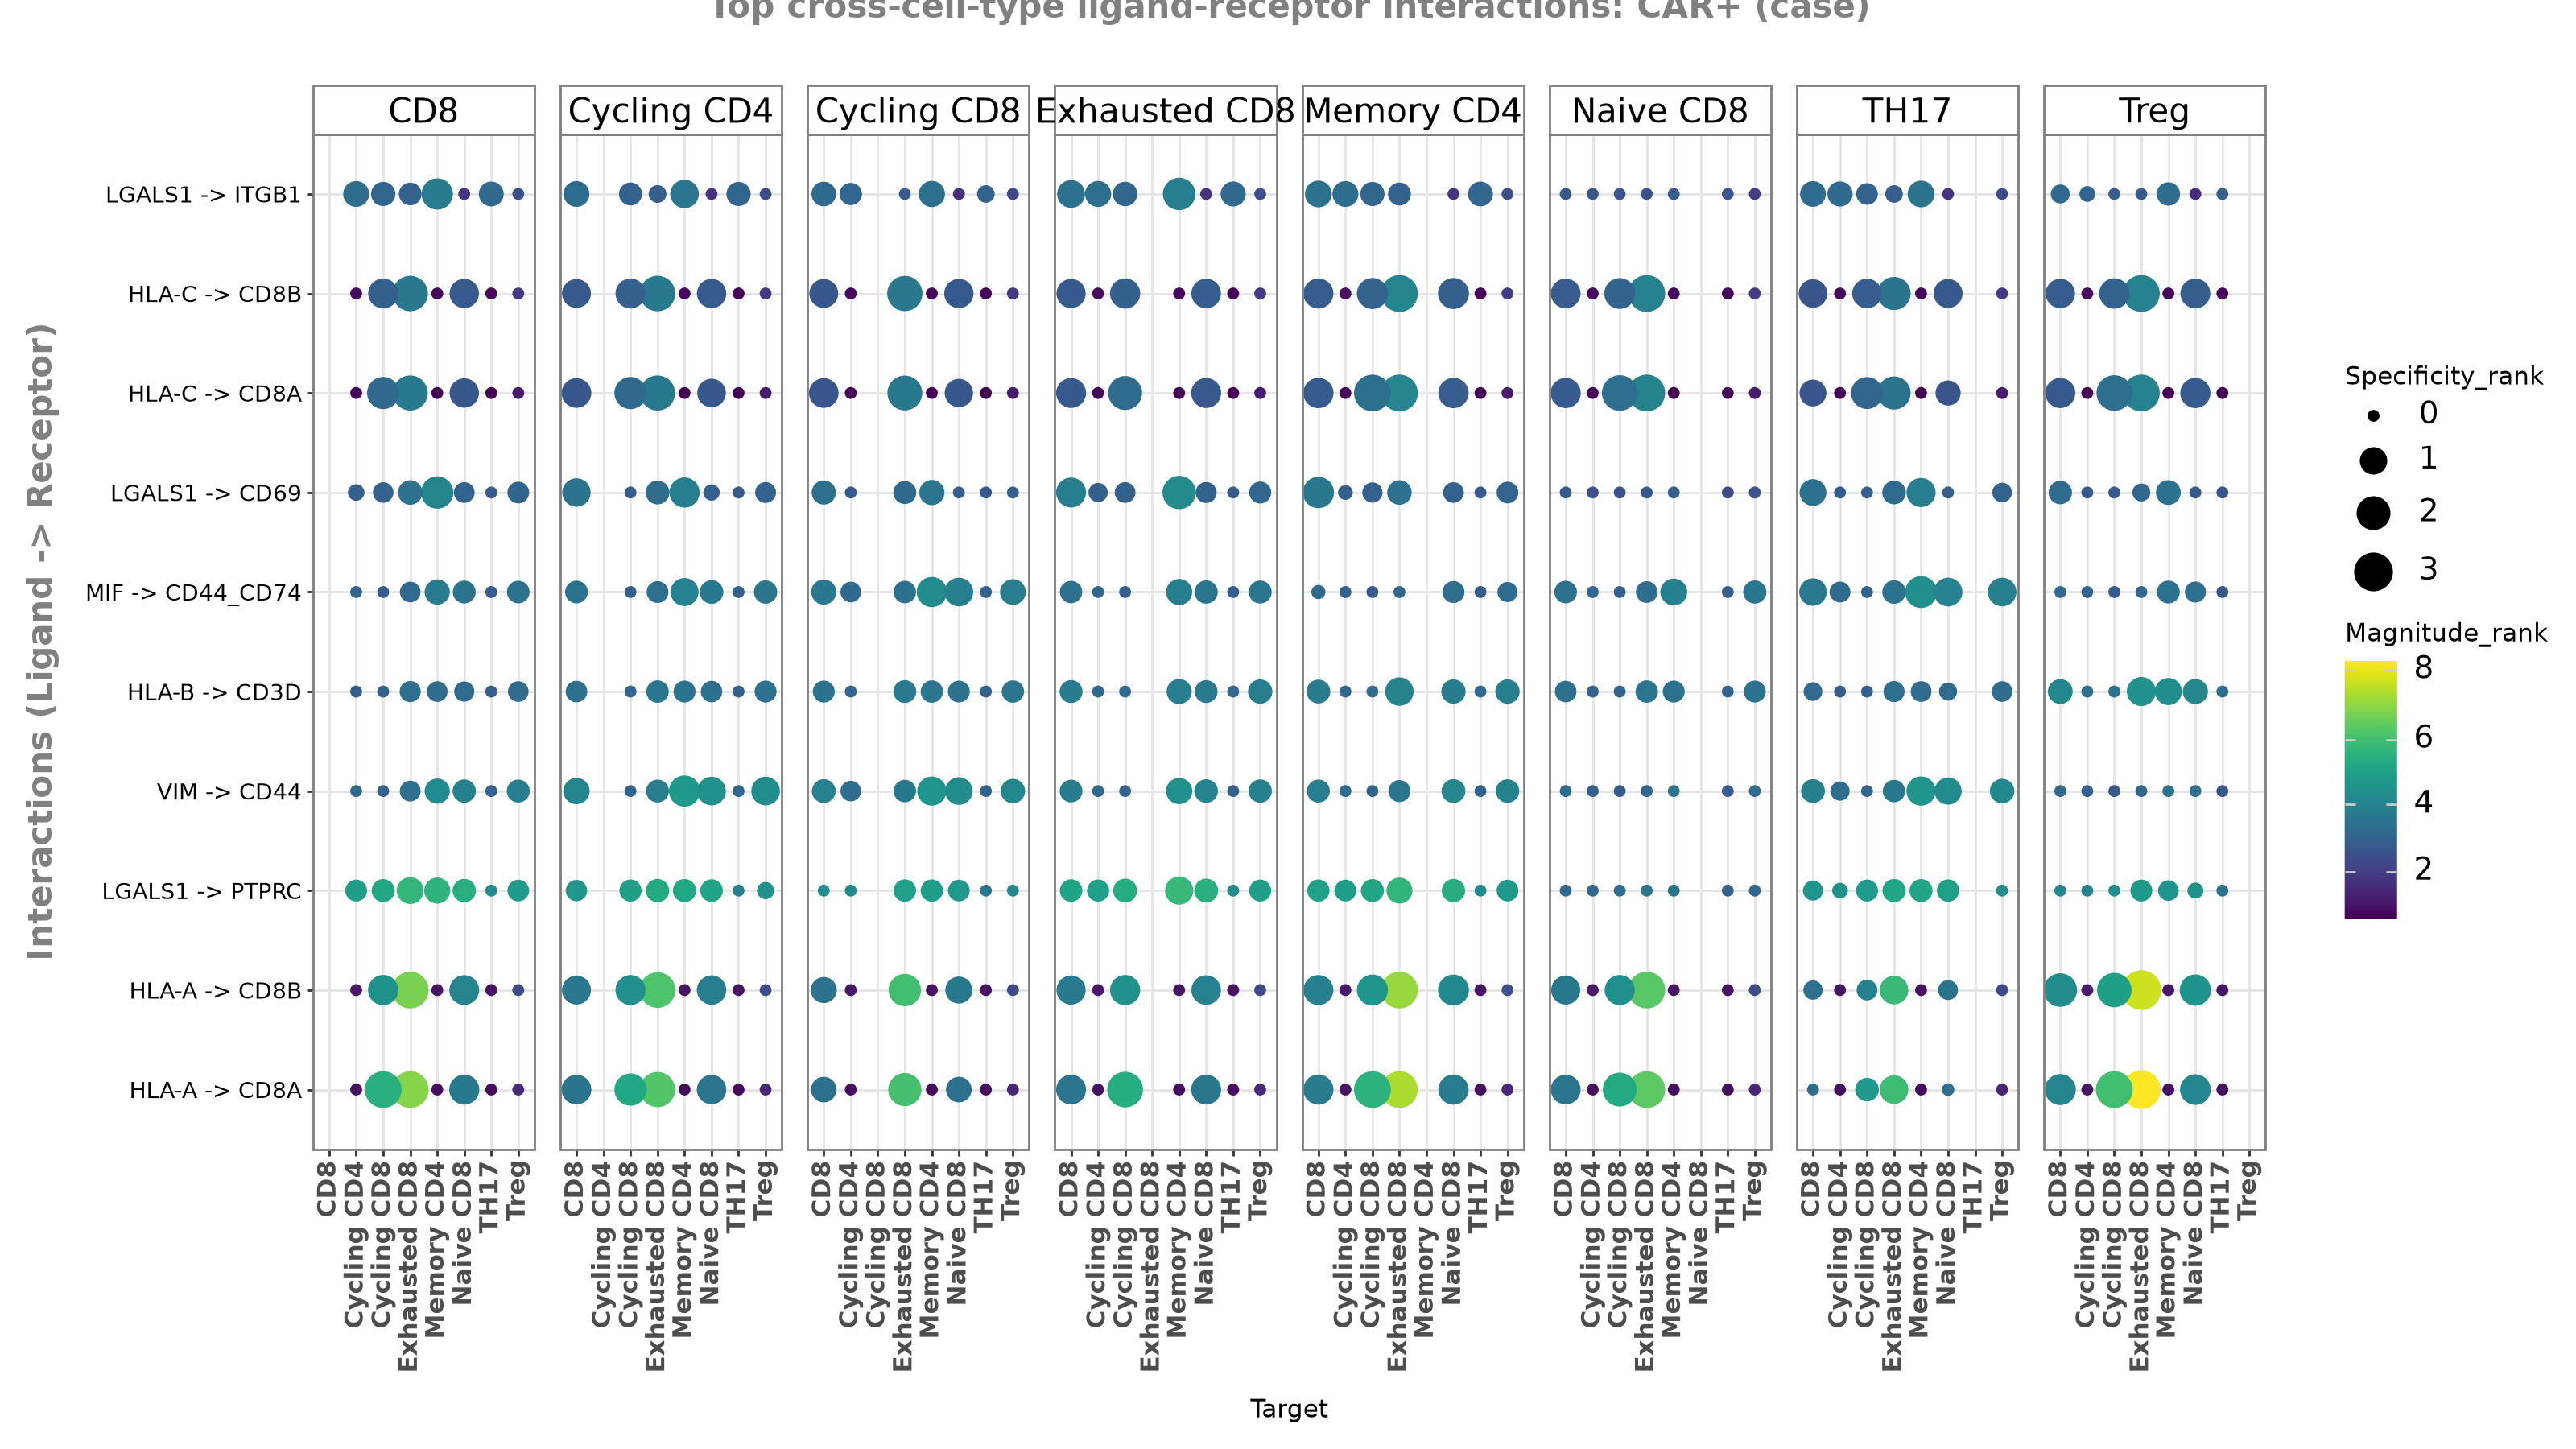

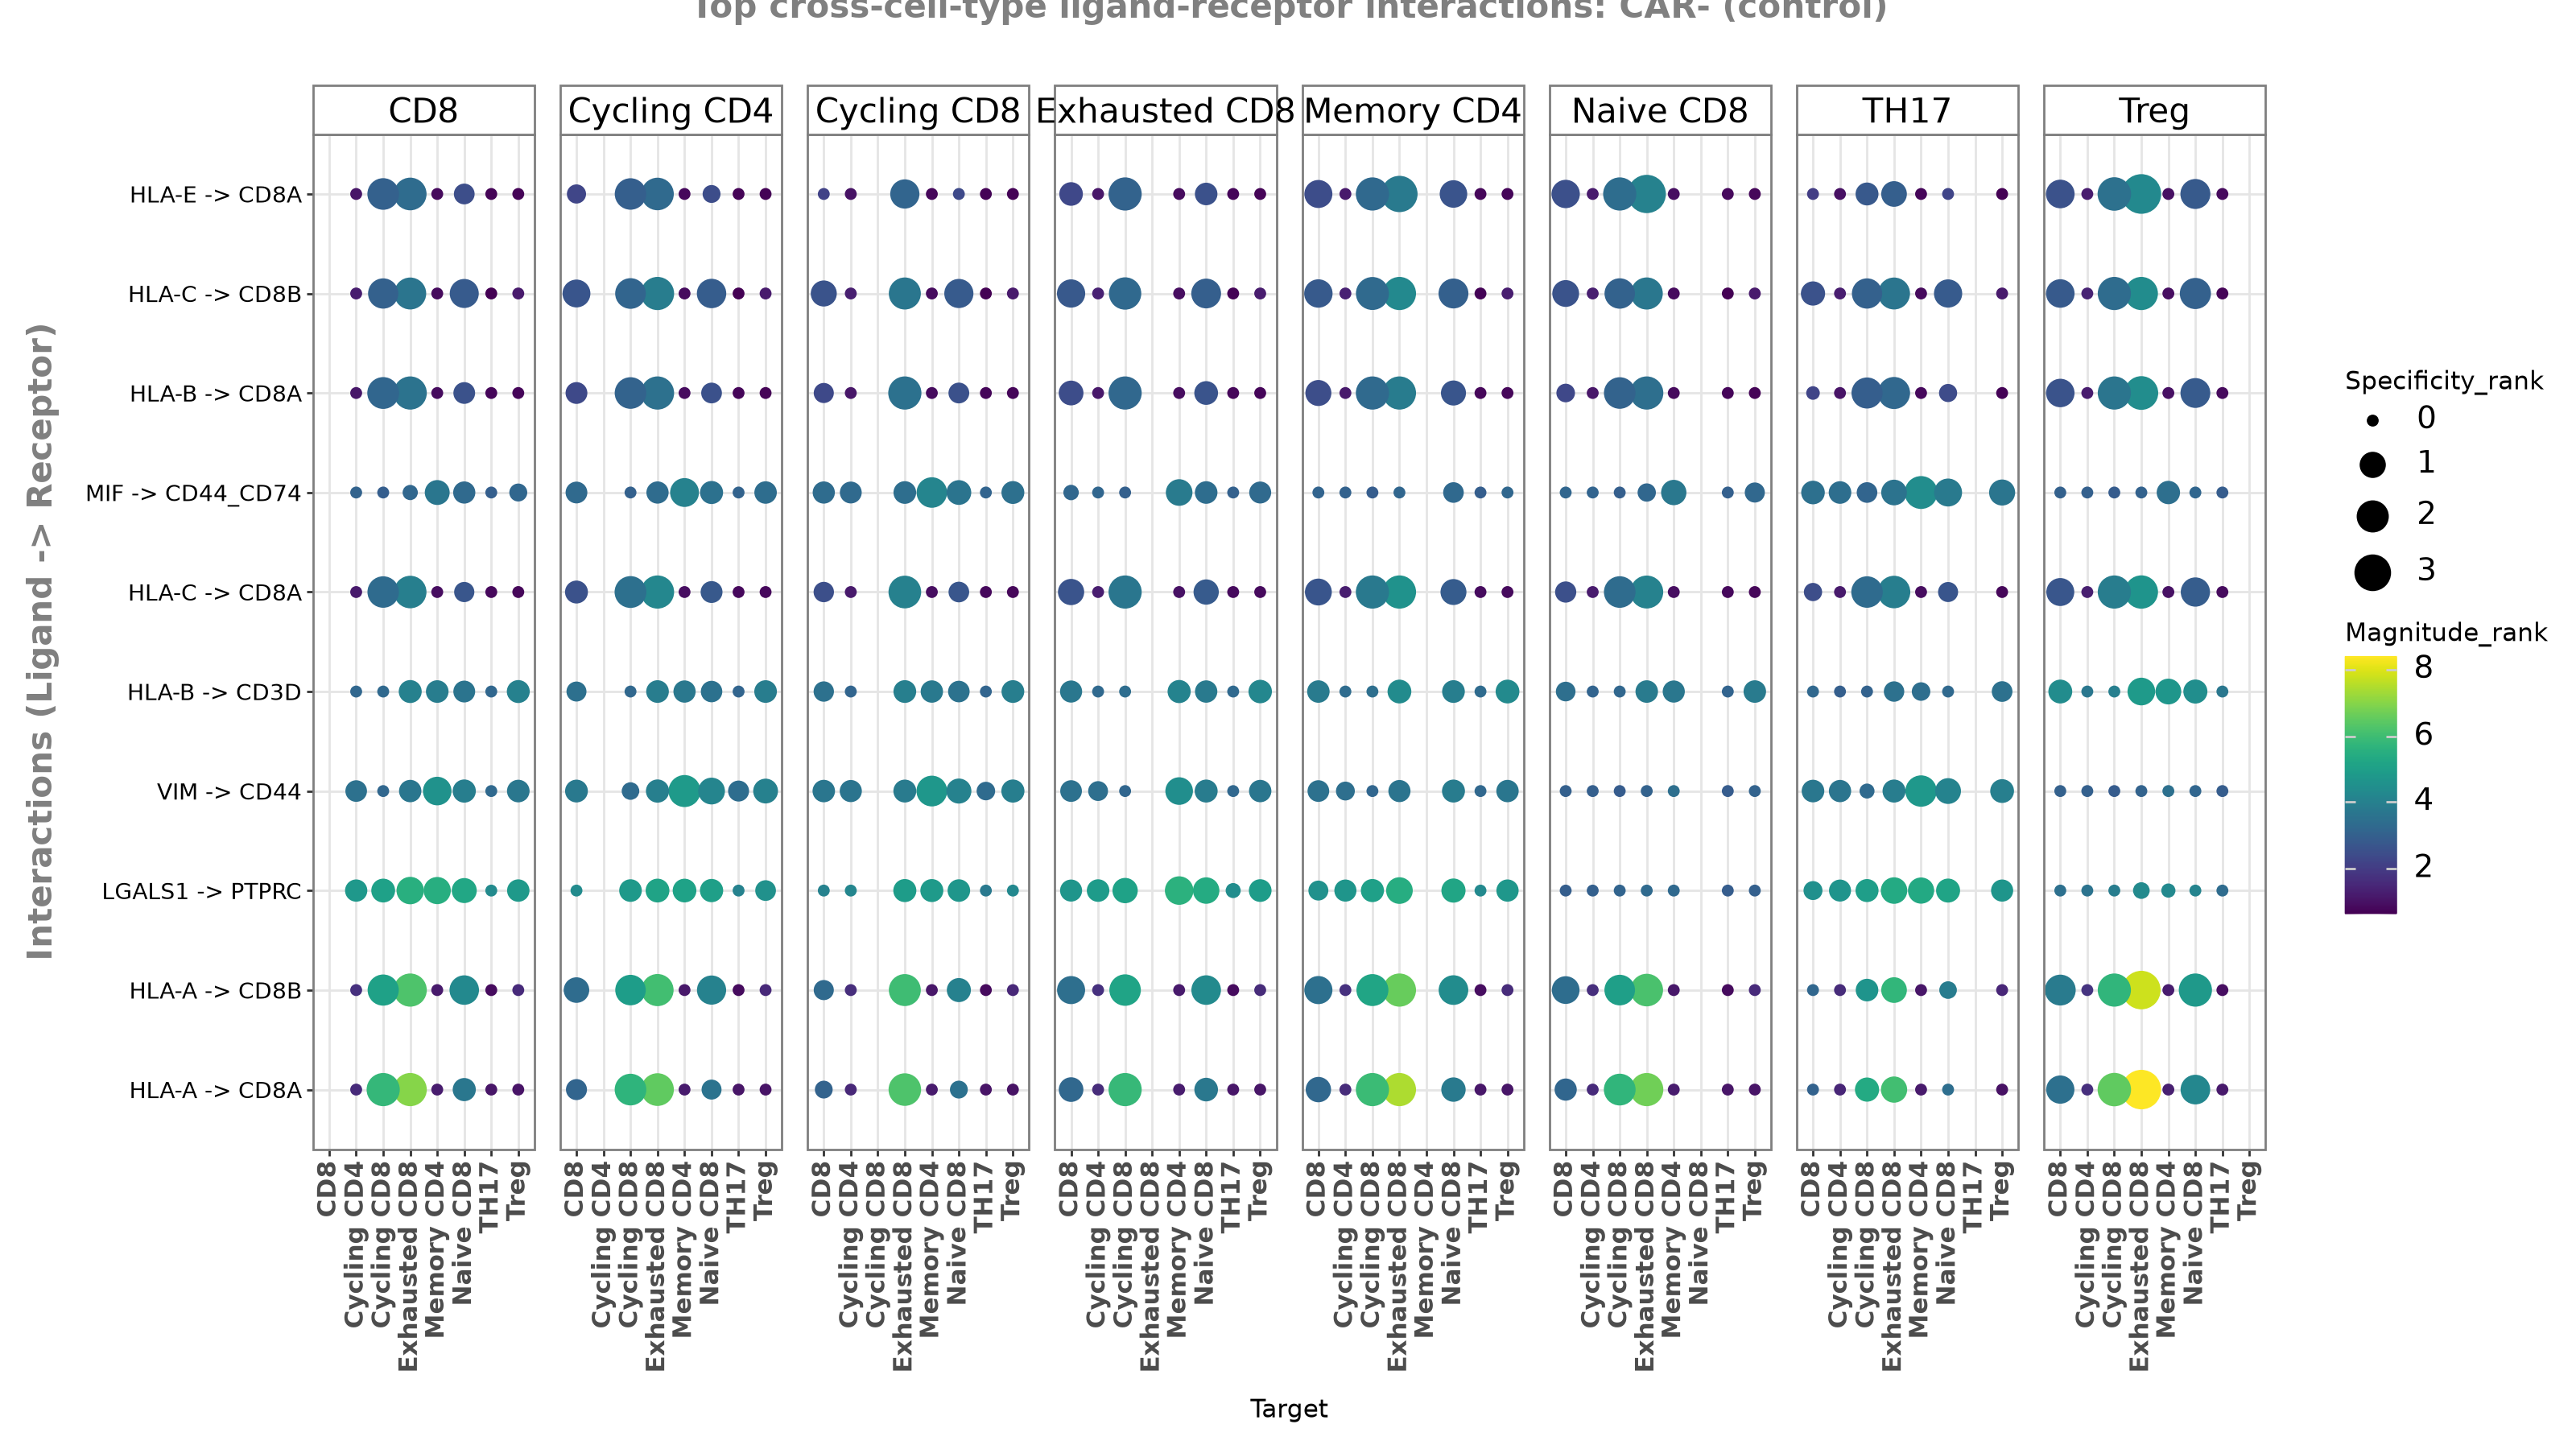

In [20]:
from IPython.display import display

for tag, title in [("case_CARpos_nonexhausted", "CAR+ (case)"), ("control_CARneg_nonexhausted", "CAR- (control)")]:
    p = li.pl.dotplot(
        liana_res=liana_results[tag], colour="magnitude_rank", size="specificity_rank",
        inverse_colour=True, inverse_size=True, top_n=10,
        orderby="magnitude_rank", orderby_ascending=True, figure_size=(16, 9),
    )
    p = p + p9.ggtitle(f"Top cross-cell-type ligand-receptor interactions: {title}")
    display(p)


### Cross-cell-type interactions disrupted by CAR transduction

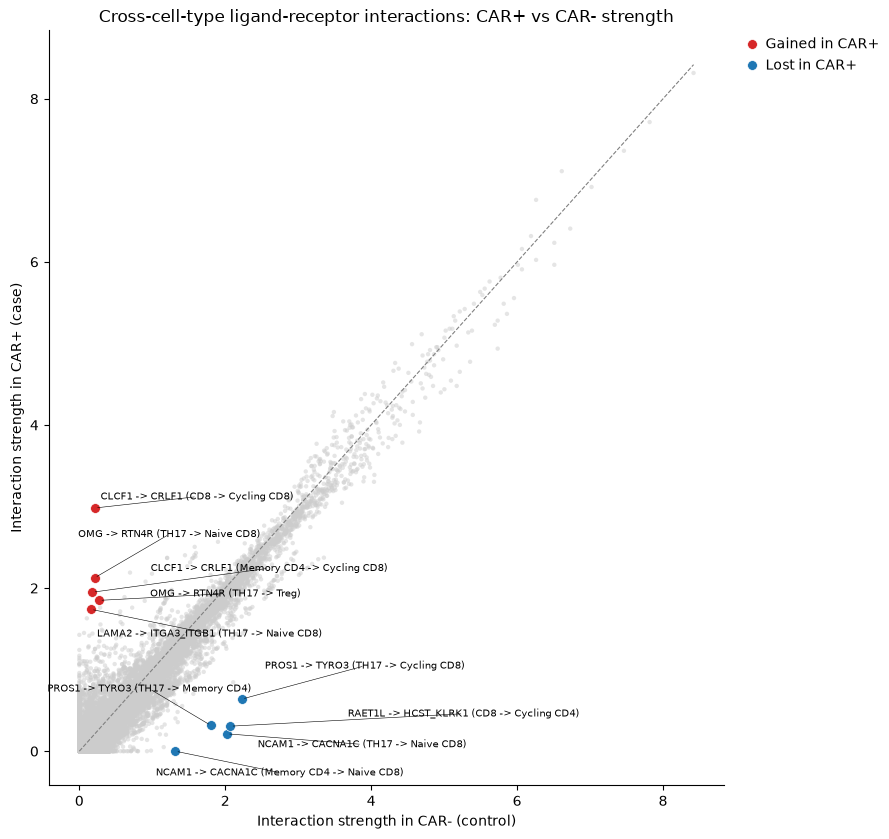

In [21]:
key_cols = ["source", "target", "ligand_complex", "receptor_complex"]
case_s = liana_results["case_CARpos_nonexhausted"][key_cols + ["magnitude_rank"]].rename(columns={"magnitude_rank": "magnitude_rank_case"})
ctrl_s = liana_results["control_CARneg_nonexhausted"][key_cols + ["magnitude_rank"]].rename(columns={"magnitude_rank": "magnitude_rank_ctrl"})
merged = pd.merge(case_s, ctrl_s, on=key_cols, how="inner")

merged["score_case"] = -np.log10(merged["magnitude_rank_case"].clip(lower=1e-12))
merged["score_ctrl"] = -np.log10(merged["magnitude_rank_ctrl"].clip(lower=1e-12))
merged["delta"] = merged["score_case"] - merged["score_ctrl"]
merged["pair_label"] = merged["ligand_complex"] + " -> " + merged["receptor_complex"] + " (" + merged["source"] + " -> " + merged["target"] + ")"

gained = merged.sort_values("delta", ascending=False).head(5)
lost = merged.sort_values("delta").head(5)

fig, ax = plt.subplots(figsize=(9, 8.5))
ax.scatter(merged["score_ctrl"], merged["score_case"], s=10, c="#CCCCCC", alpha=0.5, edgecolors="none")
ax.scatter(gained["score_ctrl"], gained["score_case"], s=50, c=CAR_PALETTE["CAR+"], label="Gained in CAR+", edgecolors="white", linewidths=0.5, zorder=3)
ax.scatter(lost["score_ctrl"], lost["score_case"], s=50, c=CAR_PALETTE["CAR-"], label="Lost in CAR+", edgecolors="white", linewidths=0.5, zorder=3)
lims = [merged[["score_ctrl", "score_case"]].min().min(), merged[["score_ctrl", "score_case"]].max().max()]
ax.plot(lims, lims, ls="--", c="gray", lw=0.8, zorder=1)
ax.set_xlabel("Interaction strength in CAR- (control)"); ax.set_ylabel("Interaction strength in CAR+ (case)")
ax.set_title("Cross-cell-type ligand-receptor interactions: CAR+ vs CAR- strength")

texts = [ax.text(row["score_ctrl"], row["score_case"], row["pair_label"], fontsize=7)
         for _, row in pd.concat([gained, lost]).iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.4),
            expand=(1.6, 1.8), force_text=(0.6, 0.8), force_points=(0.3, 0.3))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


In [22]:
print("Top interactions GAINED upon CAR transduction:")
display(gained[["pair_label", "score_ctrl", "score_case", "delta"]].reset_index(drop=True))

print("\nTop interactions LOST upon CAR transduction:")
display(lost[["pair_label", "score_ctrl", "score_case", "delta"]].reset_index(drop=True))


Top interactions GAINED upon CAR transduction:


,pair_label,score_ctrl,score_case,delta
0,CLCF1 -> CRLF1 (CD8 -> Cycling CD8),0.213216,2.982090,2.768875
1,OMG -> RTN4R (TH17 -> Naive CD8),0.208278,2.125070,1.916792
2,CLCF1 -> CRLF1 (Memory CD4 -> Cycling CD8),0.179449,1.949159,1.769710
3,LAMA2 -> ITGA3_ITGB1 (TH17 -> Naive CD8),0.157161,1.739882,1.582721
4,OMG -> RTN4R (TH17 -> Treg),0.272461,1.849185,1.576724



Top interactions LOST upon CAR transduction:


,pair_label,score_ctrl,score_case,delta
0,NCAM1 -> CACNA1C (TH17 -> Naive CD8),2.024869,0.212733,-1.812136
1,RAET1L -> HCST_KLRK1 (CD8 -> Cycling CD4),2.069636,0.306339,-1.763297
2,PROS1 -> TYRO3 (TH17 -> Cycling CD8),2.227119,0.638973,-1.588146
3,PROS1 -> TYRO3 (TH17 -> Memory CD4),1.803324,0.315553,-1.487771
4,NCAM1 -> CACNA1C (Memory CD4 -> Naive CD8),1.314381,-0.000000,-1.314381


## Summary

- Pseudobulk profiles separate primarily by cell type; the CAR+/CAR- effect is a within-cell-type shift, justifying a paired DESeq2 design.
- Paired DESeq2 (CAR+ vs CAR-, non-exhausted, n=24 donors) found a moderate but coherent transcriptional signature.
- Decoupler enrichment (ORA on Hallmarks, GSEA on PROGENy, ULM on CollecTRI) converge on the same biology: CAR transduction is associated with **increased proliferation** (E2F/MYC/G2M programs) and **decreased interferon-gamma / antigen-presentation** signaling (IRF1/STAT1/CIITA/RFX module).
- LIANA+ on cell-type-resolved pseudobulk profiles (donors as replicates), restricted to cross-cell-type signaling, identifies specific ligand-receptor pairs through which *other* T-cell subsets communicate differently with CAR+ vs CAR- cells, offering hypotheses for how CAR transduction rewires a cell's communication with its microenvironment.

This notebook is a template: swapping `group_tag` definitions (e.g. comparing exhausted vs. non-exhausted instead) reruns the same pipeline on a different contrast.
